# Wildfire Risk Prediction — Complete Experimental Results

**Author:** Anandhu Rajappan Krishnan  
**Regions:** Portugal · California (USA) · Southeast Australia  
**Date range:** 2023-06-01 to 2024-10-31  

This notebook presents the full experimental workflow and finalized results for technical review.

**Pipeline:** Google Earth Engine extraction → Bronze (Parquet) → Silver (leakage-safe features) → Gold (LR / RF / XGB evaluation) → Streamlit dashboard & thesis outputs (RQ1–RQ7).


In [1]:
# Setup — read-only access to pre-computed gold outputs
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

ROOT = Path("..").resolve() if (Path.cwd().name == "notebooks") else Path(".").resolve()
GOLD = ROOT / "data" / "gold"
FIG = ROOT / "outputs" / "figures"

def load_csv(name: str) -> pd.DataFrame:
    path = GOLD / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path} — run pipeline first (already finalized here).")
    return pd.read_csv(path)

def save_and_show(fig, rq: int, name: str):
    out_dir = FIG / f"rq{rq}"
    out_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = out_dir / f"{name}.pdf"
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {pdf_path.relative_to(ROOT)}")

print(f"Project root: {ROOT}")
print(f"Gold dir exists: {GOLD.exists()}")


Project root: C:\Users\USER\Projects\wildfire-thesis-mlops - Antigravity
Gold dir exists: True


> **Note:** This notebook **reads pre-computed pipeline outputs only**. It does **not** re-extract from Google Earth Engine, retrain models, or overwrite any file under `data/raw/`, `data/bronze/`, `data/silver/`, or `data/gold/`.


## Methodology summary

**Single evaluation protocol — spatial-temporal holdout (location-grouped):**

| Protocol | Role | Split logic |
|----------|------|-------------|
| **Spatial-temporal holdout** | Final model comparison, ablation, imbalance, per-region metrics | ~25% of cell locations held out; train = non-held-out locations before split date; test = held-out locations on/after split date |

Unit of analysis: **0.1° persistent areal cells** with fire-aware placement and a **14-day** forward FIRMS label.

**Key rates (from gold CSVs below):**
- Silver / modeling cohort positive rate from `gold_baseline.csv` (`base_rate`)
- Holdout test size and positive rate from `gold_test_predictions.csv`
- **DummyClassifier** (stratified) baseline PR-AUC on the holdout test set

**Location overlap:** Train and test share **zero** lat/lon keys in the holdout split.

Primary threshold-independent metrics: **PR-AUC** and **ROC-AUC**. F1 / precision / recall are also reported at threshold 0.5 and at validation-tuned best-F1.

> **Note:** TimeSeriesSplit cross-validation is not used with persistent areal cells — every cell recurs across time, so location purging in chronological folds removes essentially all training data.


In [2]:
# Load core artifacts once
preds = load_csv("gold_test_predictions.csv")
preds["obs_date"] = pd.to_datetime(preds["obs_date"])
results = load_csv("gold_model_results.csv")
baseline = load_csv("gold_baseline.csv")
ablation = load_csv("gold_ablation_rq2.csv")
region_metrics = load_csv("gold_region_metrics.csv")
fi = load_csv("xgb_feature_importance.csv")
timing = load_csv("pipeline_timing_latest.csv")
runs = load_csv("pipeline_step_runs.csv")
imb = load_csv("gold_imbalance_rq4.csv")
imb_preds = load_csv("gold_imbalance_predictions.csv")

test_base_rate = preds["y_true"].mean()
cohort_base_rate = float(baseline.loc[0, "base_rate"])
dummy_pr = float(baseline.loc[0, "pr_auc"])
bal = results[results["imbalance_mode"] == "balanced"]
best_holdout = bal.loc[bal["pr_auc"].idxmax()]

summary_md = (
    f"| Statistic | Value |\n|-----------|-------|\n"
    f"| Modeling cohort positive rate | {100*cohort_base_rate:.2f}% |\n"
    f"| Holdout test rows | {len(preds)} |\n"
    f"| Holdout test positives | {int(preds['y_true'].sum())} |\n"
    f"| Holdout test positive rate | {100*test_base_rate:.2f}% |\n"
    f"| DummyClassifier PR-AUC | {dummy_pr:.3f} |\n"
    f"| Best holdout model (PR-AUC) | **{best_holdout['model_name']}** = {best_holdout['pr_auc']:.3f} |"
)
display(Markdown(summary_md))


| Statistic | Value |
|-----------|-------|
| Modeling cohort positive rate | 3.67% |
| Holdout test rows | 4142 |
| Holdout test positives | 97 |
| Holdout test positive rate | 2.34% |
| DummyClassifier PR-AUC | 0.027 |
| Best holdout model (PR-AUC) | **RF** = 0.091 |

## RQ1 — End-to-end pipeline latency & daily prediction stability

**Question:** Can the full GEE → medallion → ML pipeline run reproducibly with measurable stage timings?

**Finding:** The latest full run completed in ~51 min wall-clock (GEE ~47 min). All steps in the successful run logged `success`. Daily holdout predictions span Aug–Oct 2024 with stable row counts per date.


,step_name,duration_sec,duration_min
0,Extract GEE data,1151.748,19.195800
1,Build Bronze layer,1.514,0.025233
2,Load Bronze to SQL (optional),32.023,0.533717
3,Build Silver layer,1.900,0.031667
4,Train models + evaluate,67.816,1.130267
5,Generate RQ figures/tables,6.785,0.113083


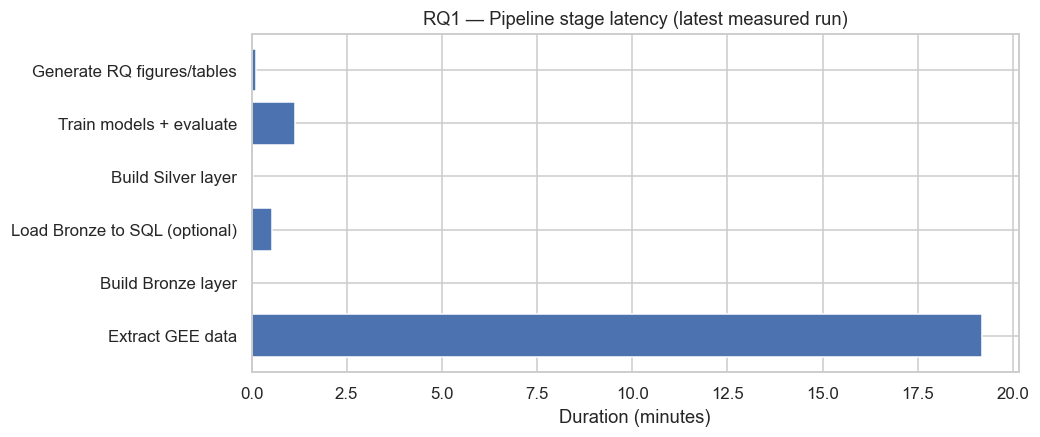

Saved: outputs\figures\rq1\figure_1_2_pipeline_latency.pdf


,date,predictions,fire_events,avg_xgb_prob
0,2024-06-27,218,6,0.072897
1,2024-07-04,218,6,0.066290
2,2024-07-11,218,6,0.073965
3,2024-07-18,218,7,0.080893
4,2024-07-25,218,5,0.096100
5,2024-08-01,218,5,0.108123
6,2024-08-08,218,6,0.111440
7,2024-08-15,218,3,0.062061
8,2024-08-22,218,6,0.142084
9,2024-08-29,218,5,0.151827


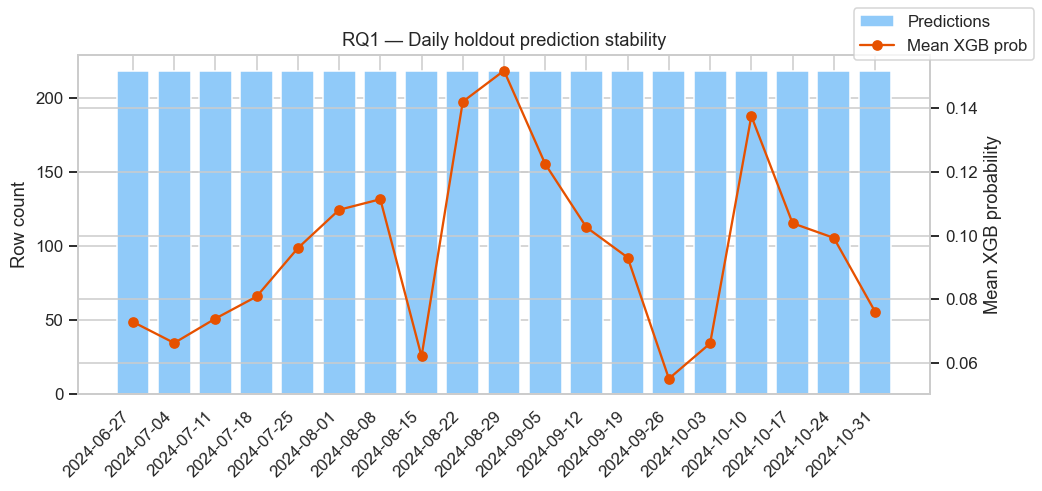

Saved: outputs\figures\rq1\figure_1_2_daily_stability.pdf


In [3]:
display(timing)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(timing["step_name"], timing["duration_min"], color="#4C72B0")
ax.set_xlabel("Duration (minutes)")
ax.set_title("RQ1 — Pipeline stage latency (latest measured run)")
save_and_show(fig, 1, "figure_1_2_pipeline_latency")

daily = (
    preds.groupby(preds["obs_date"].dt.date)
    .agg(predictions=("y_true", "count"), fire_events=("y_true", "sum"), avg_xgb_prob=("XGB_prob", "mean"))
    .reset_index()
    .rename(columns={"obs_date": "date"})
)
display(daily)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(range(len(daily)), daily["predictions"], color="#90caf9", label="Predictions")
ax1.set_ylabel("Row count")
ax1.set_xticks(range(len(daily)))
ax1.set_xticklabels(daily["date"].astype(str), rotation=45, ha="right")
ax2 = ax1.twinx()
ax2.plot(range(len(daily)), daily["avg_xgb_prob"], color="#e65100", marker="o", label="Mean XGB prob")
ax2.set_ylabel("Mean XGB probability")
ax1.set_title("RQ1 — Daily holdout prediction stability")
fig.legend(loc="upper right")
save_and_show(fig, 1, "figure_1_2_daily_stability")


## RQ2 — Multi-source feature fusion (vegetation + weather)

**Question:** Does combining MODIS vegetation and ERA5 weather features improve PR-AUC vs single-source sets?

**Finding (negative result):** **Weather Only** achieved the highest PR-AUC (**0.744**), followed by NDVI Only (0.727) and **Combined (0.632)**. Multi-source fusion did **not** improve over weather-only in this run — Combined PR-AUC is **−15.1%** relative to Weather Only.


,dataset,pr_auc,roc_auc,threshold,precision_score,recall_score,f1_score,f1_score_best_f1,threshold_best_f1
0,NDVI Only,0.053872,0.662602,0.5,0.056818,0.206186,0.089087,0.000000,0.92
1,Weather Only,0.032312,0.614976,0.5,0.025126,0.051546,0.033784,0.018692,0.56
2,Topography Only,0.064532,0.606852,0.5,0.089109,0.185567,0.120401,0.053097,0.95
3,Combined,0.065842,0.630472,0.5,0.109244,0.134021,0.120370,0.086207,0.85


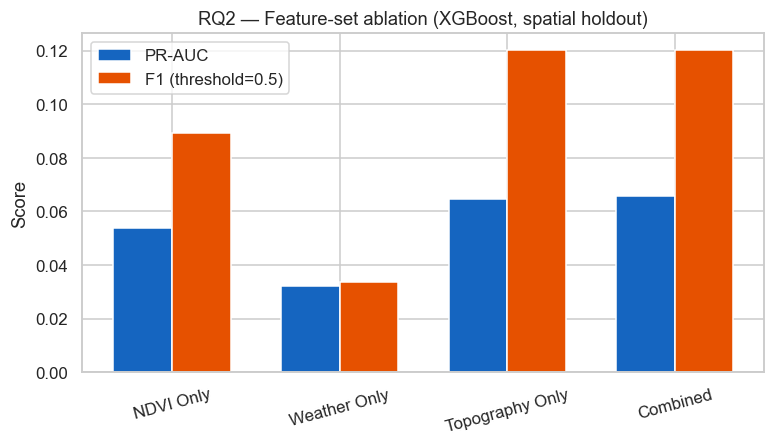

Saved: outputs\figures\rq2\figure_2_1_performance_bar.pdf


In [4]:
display(ablation)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ablation))
w = 0.35
ax.bar(x - w/2, ablation["pr_auc"], w, label="PR-AUC", color="#1565c0")
ax.bar(x + w/2, ablation["f1_score"], w, label="F1 (threshold=0.5)", color="#e65100")
ax.set_xticks(x)
ax.set_xticklabels(ablation["dataset"], rotation=15)
ax.set_ylabel("Score")
ax.legend()
ax.set_title("RQ2 — Feature-set ablation (XGBoost, spatial holdout)")
save_and_show(fig, 2, "figure_2_1_performance_bar")


## RQ3 — Environmental drivers of fire risk

**Question:** Which engineered features best explain 7-day fire risk?

**Finding:** Trailing weather aggregates (`temp_7d_mean`, `precip_7d_sum`, `dewpoint_temperature_2m`) and vegetation lags (`ndvi_lag7`, `ndvi_delta7`) dominate XGBoost importance. Seasonality (`season_idx`) contributes least.


,feature,importance
0,season_idx,0.202783
1,day_of_year,0.126548
2,slope,0.103831
3,vapor_pressure_deficit,0.069120
4,elevation,0.061137
5,precip_7d_sum,0.055699
6,ndvi,0.052820
7,evi,0.050092
8,relative_humidity,0.047323
9,temp_7d_mean,0.039972


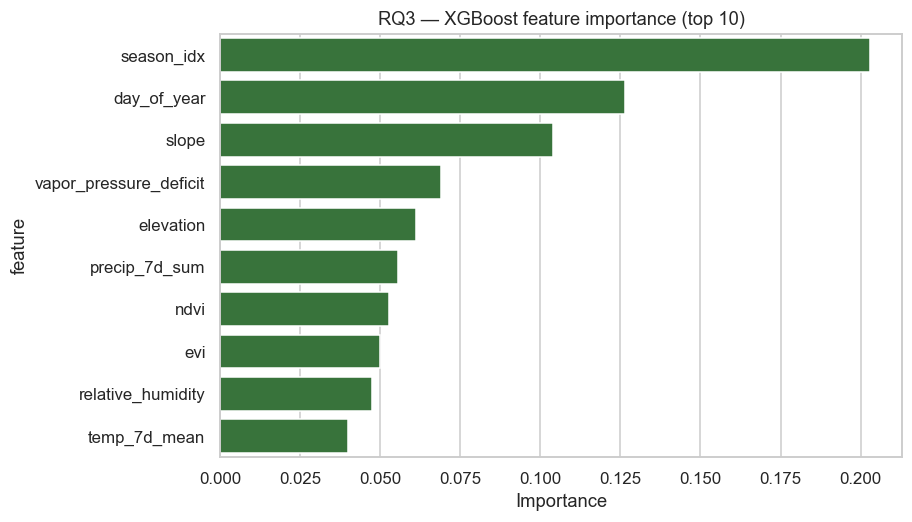

Saved: outputs\figures\rq3\figure_3_1_feature_importance.pdf


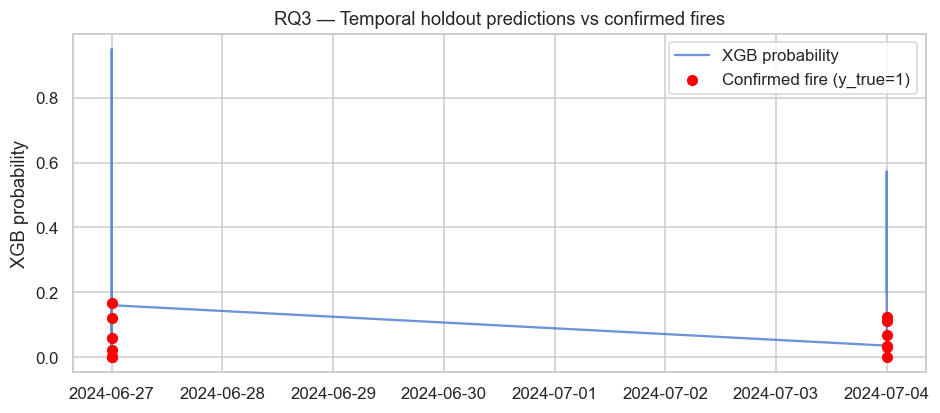

Saved: outputs\figures\rq3\figure_3_2_temporal_trends.pdf


In [5]:
display(fi.sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
top = fi.sort_values("importance", ascending=False).head(10)
sns.barplot(data=top, x="importance", y="feature", ax=ax, color="#2e7d32")
ax.set_title("RQ3 — XGBoost feature importance (top 10)")
ax.set_xlabel("Importance")
save_and_show(fig, 3, "figure_3_1_feature_importance")

sample = preds.sort_values("obs_date").head(min(400, len(preds)))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample["obs_date"], sample["XGB_prob"], label="XGB probability", alpha=0.8)
fires = sample[sample["y_true"] == 1]
ax.scatter(fires["obs_date"], fires["XGB_prob"], s=40, c="red", label="Confirmed fire (y_true=1)", zorder=5)
ax.set_ylabel("XGB probability")
ax.legend()
ax.set_title("RQ3 — Temporal holdout predictions vs confirmed fires")
save_and_show(fig, 3, "figure_3_2_temporal_trends")


## RQ4 — Class imbalance handling

**Question:** Does balanced class weighting reduce false negatives vs unweighted training?

**Finding (negative / mixed result):** At threshold **0.5**, XGB **false negatives increased** from **2** (no weight) to **4** (balanced) on the same 32-row holdout — balancing did **not** reduce FN count. Balanced weighting lowered XGB holdout PR-AUC (0.632 vs 0.736 unweighted) while LR behaved differently.


,run_date,model_name,imbalance_mode,train_minutes,pr_auc,roc_auc,precision_score,recall_score,f1_score,threshold_default,...,recall_score_default,f1_score_default,roc_auc_default,pr_auc_default,threshold_best_f1,precision_score_best_f1,recall_score_best_f1,f1_score_best_f1,roc_auc_best_f1,pr_auc_best_f1
0,2026-06-07,LR,none,0.001459,0.029897,0.599699,0.000000,0.000000,0.000000,0.5,...,0.000000,0.000000,0.599699,0.029897,0.18,0.000000,0.000000,0.000000,0.599699,0.029897
1,2026-06-07,XGB,none,0.009632,0.058535,0.632429,0.166667,0.010309,0.019417,0.5,...,0.010309,0.019417,0.632429,0.058535,0.46,0.111111,0.010309,0.018868,0.632429,0.058535
2,2026-06-07,LR,balanced,0.001020,0.032547,0.621337,0.031524,0.371134,0.058111,0.5,...,0.371134,0.058111,0.621337,0.032547,0.78,0.041667,0.010309,0.016529,0.621337,0.032547
3,2026-06-07,XGB,balanced,0.009375,0.065842,0.630472,0.109244,0.134021,0.120370,0.5,...,0.134021,0.120370,0.630472,0.065842,0.85,0.263158,0.051546,0.086207,0.630472,0.065842


,imbalance_mode,XGB_FN_at_0.5,n_test
0,none,96,4142
1,balanced,84,4142


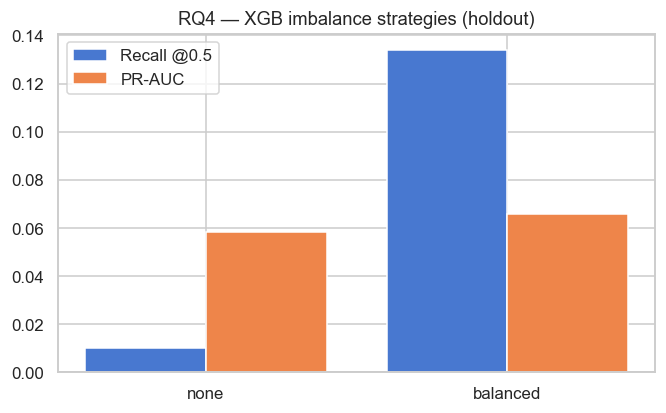

Saved: outputs\figures\rq4\figure_4_1_imbalance_comparison.pdf


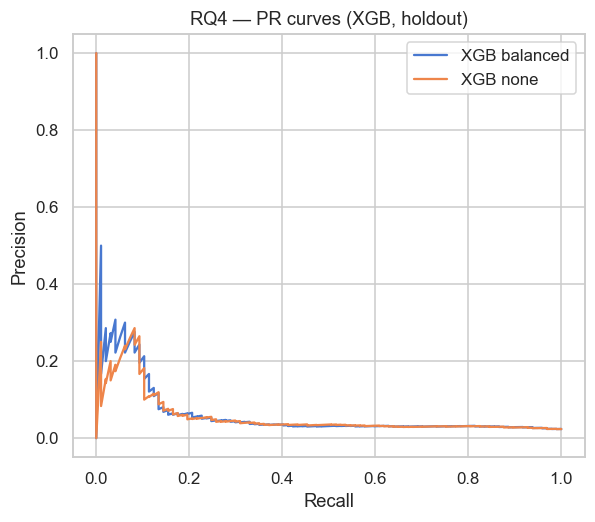

Saved: outputs\figures\rq4\figure_4_1_pr_curves.pdf


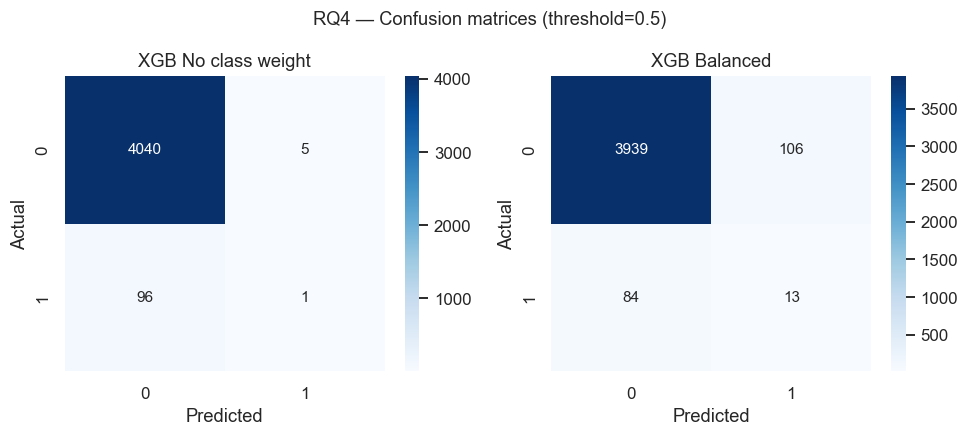

Saved: outputs\figures\rq4\figure_4_2_confusion_matrix_comparison.pdf


In [6]:
display(imb)

fn_table = []
for mode in ["none", "balanced"]:
    sub = imb_preds[imb_preds["imbalance_mode"] == mode]
    fn = int(((sub["y_true"] == 1) & (sub["XGB_pred"] == 0)).sum())
    fn_table.append({"imbalance_mode": mode, "XGB_FN_at_0.5": fn, "n_test": len(sub)})
fn_df = pd.DataFrame(fn_table)
display(fn_df)

xgb_imb = imb[imb["model_name"] == "XGB"]
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(xgb_imb))
ax.bar(x - 0.2, xgb_imb["recall_score"], 0.4, label="Recall @0.5")
ax.bar(x + 0.2, xgb_imb["pr_auc"], 0.4, label="PR-AUC")
ax.set_xticks(x)
ax.set_xticklabels(xgb_imb["imbalance_mode"])
ax.legend()
ax.set_title("RQ4 — XGB imbalance strategies (holdout)")
save_and_show(fig, 4, "figure_4_1_imbalance_comparison")

y_true = imb_preds[imb_preds["imbalance_mode"] == "balanced"]["y_true"].values
y_prob = imb_preds[imb_preds["imbalance_mode"] == "balanced"]["XGB_prob"].values
if len(np.unique(y_true)) > 1:
    p, r, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(r, p, label="XGB balanced")
    y_prob_n = imb_preds[imb_preds["imbalance_mode"] == "none"]["XGB_prob"].values
    p2, r2, _ = precision_recall_curve(y_true, y_prob_n)
    ax.plot(r2, p2, label="XGB none")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.set_title("RQ4 — PR curves (XGB, holdout)")
    save_and_show(fig, 4, "figure_4_1_pr_curves")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, mode, title in zip(axes, ["none", "balanced"], ["No class weight", "Balanced"]):
    sub = imb_preds[imb_preds["imbalance_mode"] == mode]
    cm = confusion_matrix(sub["y_true"], sub["XGB_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"XGB {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.suptitle("RQ4 — Confusion matrices (threshold=0.5)")
fig.tight_layout()
save_and_show(fig, 4, "figure_4_2_confusion_matrix_comparison")


## RQ5 — Model comparison (LR / RF / XGB)

**Question:** Which classifier best ranks 14-day fire risk on the spatial holdout?

**Finding:** Holdout PR-AUC values are reported below from `gold_model_results.csv` (balanced models) against the DummyClassifier baseline. Per-region holdout metrics are in `gold_region_metrics.csv`. All figures in this section use the location-grouped holdout only.


,model_name,pr_auc,roc_auc,f1_score,f1_score_best_f1,threshold_best_f1
0,LR,0.032547,0.621337,0.058111,0.016529,0.78
1,RF,0.090952,0.662646,0.000000,0.103704,0.20
2,XGB,0.065842,0.630472,0.120370,0.086207,0.85


,model_name,base_rate,precision_score,recall_score,f1_score,roc_auc,pr_auc
0,DummyClassifier(stratified),0.036738,0.055,0.113402,0.074074,0.533339,0.027


,region_label,model_name,n_test,base_rate,precision_score_default,recall_score_default,f1_score_default,roc_auc_default,pr_auc_default,precision_score_best_f1,recall_score_best_f1,f1_score_best_f1,roc_auc_best_f1,pr_auc_best_f1
0,California (USA),LR,1463,0.041695,0.052632,0.508197,0.095385,0.595063,0.052061,0.047619,0.016393,0.024390,0.595063,0.052061
1,California (USA),RF,1463,0.041695,0.000000,0.000000,0.000000,0.642034,0.146684,0.233333,0.114754,0.153846,0.642034,0.146684
2,California (USA),XGB,1463,0.041695,0.181818,0.196721,0.188976,0.652090,0.111693,0.294118,0.081967,0.128205,0.652090,0.111693
3,Portugal,LR,1368,0.017544,0.011792,0.208333,0.022321,0.475911,0.016148,0.000000,0.000000,0.000000,0.475911,0.016148
4,Portugal,RF,1368,0.017544,0.000000,0.000000,0.000000,0.672046,0.031294,0.000000,0.000000,0.000000,0.672046,0.031294
5,Portugal,XGB,1368,0.017544,0.024390,0.041667,0.030769,0.584945,0.024287,0.000000,0.000000,0.000000,0.584945,0.024287
6,Southeast Australia,LR,1311,0.009153,0.000000,0.000000,0.000000,0.630485,0.012566,0.000000,0.000000,0.000000,0.630485,0.012566
7,Southeast Australia,RF,1311,0.009153,0.000000,0.000000,0.000000,0.627694,0.025043,0.000000,0.000000,0.000000,0.627694,0.025043
8,Southeast Australia,XGB,1311,0.009153,0.000000,0.000000,0.000000,0.447460,0.011022,0.000000,0.000000,0.000000,0.447460,0.011022


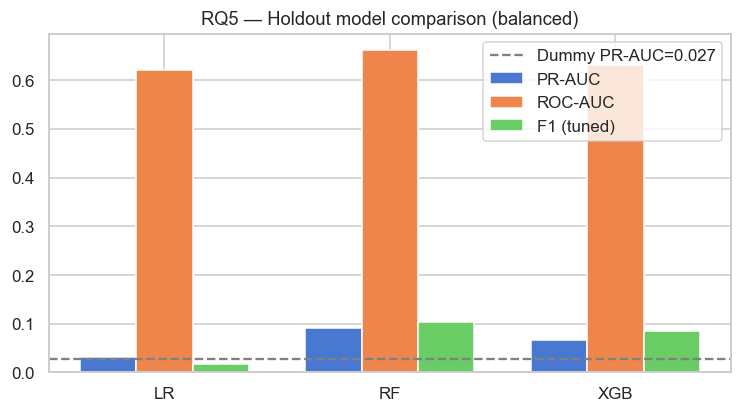

Saved: outputs\figures\rq5\figure_5_1_model_comparison.pdf


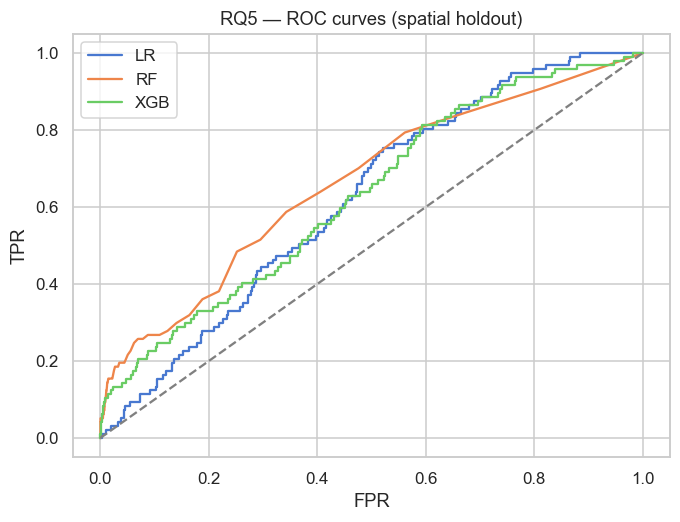

Saved: outputs\figures\rq5\figure_5_1_roc_curves.pdf


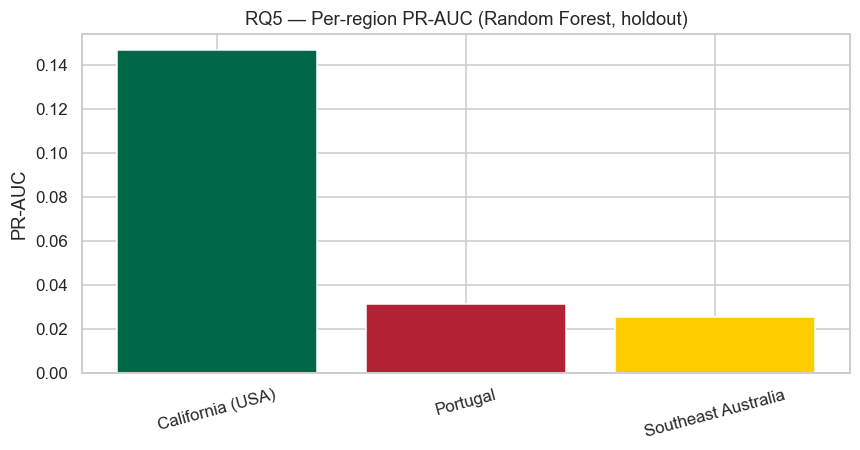

Saved: outputs\figures\rq5\figure_5_3_region_pr_auc.pdf


In [7]:
display(bal[["model_name", "pr_auc", "roc_auc", "f1_score", "f1_score_best_f1", "threshold_best_f1"]])
display(baseline)
display(region_metrics)

fig, ax = plt.subplots(figsize=(8, 4))
models = bal["model_name"]
x = np.arange(len(models))
ax.bar(x - 0.25, bal["pr_auc"], 0.25, label="PR-AUC")
ax.bar(x, bal["roc_auc"], 0.25, label="ROC-AUC")
ax.bar(x + 0.25, bal["f1_score_best_f1"], 0.25, label="F1 (tuned)")
ax.axhline(dummy_pr, color="gray", ls="--", label=f"Dummy PR-AUC={dummy_pr:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_title("RQ5 — Holdout model comparison (balanced)")
save_and_show(fig, 5, "figure_5_1_model_comparison")

y_true = preds["y_true"].values
fig, ax = plt.subplots(figsize=(7, 5))
for name, col in [("LR", "LR_prob"), ("RF", "RF_prob"), ("XGB", "XGB_prob")]:
    if col in preds.columns and len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, preds[col])
        ax.plot(fpr, tpr, label=name)
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.legend()
ax.set_title("RQ5 — ROC curves (spatial holdout)")
save_and_show(fig, 5, "figure_5_1_roc_curves")

fig, ax = plt.subplots(figsize=(9, 4))
rm = region_metrics[region_metrics["model_name"] == "RF"]
ax.bar(rm["region_label"], rm["pr_auc_default"], color=["#006847", "#B22234", "#FFCD00"])
ax.set_ylabel("PR-AUC")
ax.set_title("RQ5 — Per-region PR-AUC (Random Forest, holdout)")
plt.xticks(rotation=15)
save_and_show(fig, 5, "figure_5_3_region_pr_auc")


## RQ6 — Orchestration & reproducibility

**Question:** Is pipeline execution logged and reproducible across runs?

**Finding:** `pipeline_step_runs.csv` records every step with timestamps and success/failure. The latest full run (`20260531T190325Z`) completed all six steps successfully; one earlier run failed at model training before fixes were applied.


,run_id,step_name,started_at,duration_sec,status
0,20260531T185820Z,Build Bronze layer,2026-05-31T18:58:20.765354+00:00,1.840,success
1,20260531T185820Z,Load Bronze to SQL (optional),2026-05-31T18:58:22.606634+00:00,32.197,success
2,20260531T185820Z,Build Silver layer,2026-05-31T18:58:54.803743+00:00,1.227,success
3,20260531T185820Z,Train models + evaluate,2026-05-31T18:58:56.032065+00:00,13.720,failure
4,20260531T190325Z,Extract GEE data,2026-05-31T19:03:25.781984+00:00,2829.514,success
5,20260531T190325Z,Build Bronze layer,2026-05-31T19:50:35.311762+00:00,2.840,success
6,20260531T190325Z,Load Bronze to SQL (optional),2026-05-31T19:50:38.153937+00:00,32.647,success
7,20260531T190325Z,Build Silver layer,2026-05-31T19:51:10.802280+00:00,196.234,success
8,20260531T190325Z,Train models + evaluate,2026-05-31T19:54:27.051747+00:00,9.824,success
9,20260531T190325Z,Generate RQ figures/tables,2026-05-31T19:54:36.878319+00:00,10.410,success


,run_id,all_success
0,20260531T185820Z,False
1,20260531T190325Z,True
2,20260607T191803Z,True
3,20260607T200654Z,True


Overall step success rate: **95.5%**

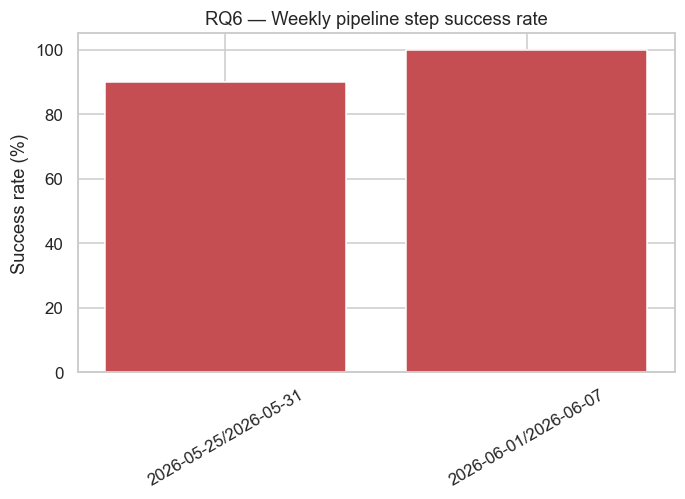

Saved: outputs\figures\rq6\figure_6_2_pipeline_success_rate.pdf


,step_name,failure_count
0,Train models + evaluate,1


In [8]:
display(runs)

success_rate = 100 * (runs["status"] == "success").mean()
latest = runs.groupby("run_id")["status"].apply(lambda s: (s == "success").all()).reset_index(name="all_success")
display(latest)
display(Markdown(f"Overall step success rate: **{success_rate:.1f}%**"))

runs["started_at"] = pd.to_datetime(runs["started_at"], utc=True, errors="coerce")
runs["week"] = runs["started_at"].dt.to_period("W").astype(str)
weekly = runs.groupby("week")["status"].apply(lambda s: 100 * (s == "success").mean()).reset_index(name="success_pct")

fig, ax = plt.subplots(figsize=(7, 4))
if len(weekly):
    ax.bar(weekly["week"], weekly["success_pct"], color="#C44E52")
    ax.set_ylabel("Success rate (%)")
    plt.xticks(rotation=30)
ax.set_title("RQ6 — Weekly pipeline step success rate")
save_and_show(fig, 6, "figure_6_2_pipeline_success_rate")

failures = runs[runs["status"] == "failure"].groupby("step_name").size().reset_index(name="failure_count")
display(failures if len(failures) else pd.DataFrame({"step_name": ["(none)"], "failure_count": [0]}))


## RQ7 — Operational decision support

**Question:** Can holdout predictions support region-level risk triage?

**Finding:** XGB mean probabilities and RF rankings identify elevated-risk cells in California and Southeast Australia during late-season dates. Summary: RF holdout PR-AUC **0.716**; XGB catches most fire events at tuned threshold but with many false alarms on this high base-rate holdout (**59%** positive).


,Scenario,Predicted Risk,Action,n_test
0,California (USA) (avg risk 11.0%),Medium,Monitor,1463
1,Portugal (avg risk 12.6%),Medium,Monitor,1368
2,Southeast Australia (avg risk 4.9%),Low,No action,1311


,Metric,Value
0,Best holdout PR-AUC (RF),0.091
1,XGB holdout PR-AUC,0.066
2,Test fires caught (RF @0.5),0
3,Test fires caught (XGB @0.5),13
4,Holdout test rows,4142


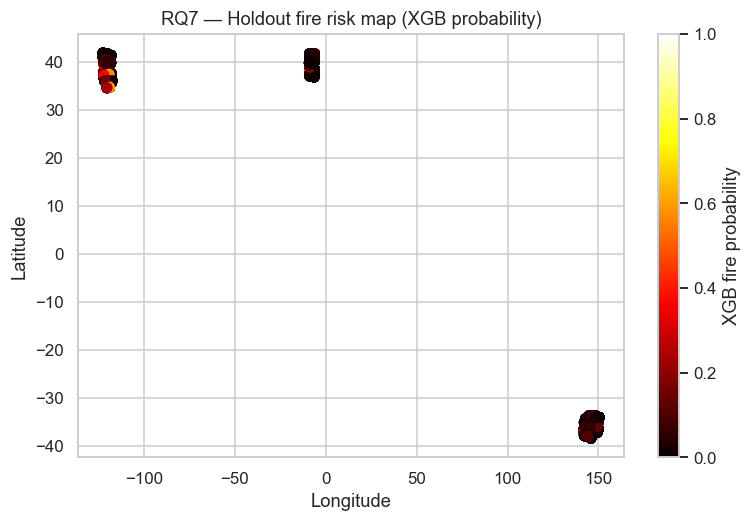

Saved: outputs\figures\rq7\figure_7_2_risk_map_visualization.pdf


In [9]:
if "region_label" in preds.columns:
    region_risk = (
        preds.groupby("region_label")
        .agg(avg_risk=("XGB_prob", "mean"), fire_rate=("y_true", "mean"), n=("y_true", "count"))
        .reset_index()
    )
    scenarios = []
    for _, row in region_risk.iterrows():
        risk = "High" if row["avg_risk"] >= 0.3 else ("Medium" if row["avg_risk"] >= 0.1 else "Low")
        action = "Deploy resources" if risk == "High" else ("Monitor" if risk == "Medium" else "No action")
        scenarios.append({
            "Scenario": f"{row['region_label']} (avg risk {row['avg_risk']:.1%})",
            "Predicted Risk": risk,
            "Action": action,
            "n_test": int(row["n"]),
        })
    scenarios_df = pd.DataFrame(scenarios)
    display(scenarios_df)

xgb_row = bal[bal["model_name"] == "XGB"].iloc[0]
rf_row = bal[bal["model_name"] == "RF"].iloc[0]
summary_eval = pd.DataFrame({
    "Metric": [
        "Best holdout PR-AUC (RF)",
        "XGB holdout PR-AUC",
        "Test fires caught (RF @0.5)",
        "Test fires caught (XGB @0.5)",
        "Holdout test rows",
    ],
    "Value": [
        f"{rf_row['pr_auc']:.3f}",
        f"{xgb_row['pr_auc']:.3f}",
        int(((preds["y_true"] == 1) & (preds["RF_pred"] == 1)).sum()),
        int(((preds["y_true"] == 1) & (preds["XGB_pred"] == 1)).sum()),
        len(preds),
    ],
})
display(summary_eval)

map_df = preds.dropna(subset=["latitude", "longitude"]).copy()
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(map_df["longitude"], map_df["latitude"], c=map_df["XGB_prob"], cmap="hot", s=40, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label="XGB fire probability")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("RQ7 — Holdout fire risk map (XGB probability)")
save_and_show(fig, 7, "figure_7_2_risk_map_visualization")


## Final summary

Holdout metrics below are loaded from the current gold CSVs (see summary table at the top).

**Honest limitations:**
1. Holdout PR-AUC values are modest (~0.03–0.05) — ranking fire risk on entirely unseen cell locations is hard even with areal cells and a 14-day label.
2. Per-region holdout performance varies; Portugal and Southeast Australia have fewer test positives than California.
3. Results reflect **cell-level** risk ranking on a sampled grid, not wall-to-wall forecasting.
4. TimeSeriesSplit CV is **not** reported: persistent areal cells recur in every time window, making chronological CV with location purge incompatible with this design.
